<a href="https://colab.research.google.com/github/nameershah/ml-salary-prediction/blob/main/Simple_Linear_Regression_Salary_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
# ── Cell 1: Install libraries (only needed if not on Colab) ──────────────────
!pip install pandas numpy matplotlib scikit-learn seaborn

In [64]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [65]:
# ── Cell 3: Load Dataset ─────────────────────────────────────────────────────
df = pd.read_csv('Salary_dataset.csv')
df = df.drop(columns=['Unnamed: 0'])

In [66]:
# ── Cell 4: Exploratory Data Analysis (EDA) ──────────────────────────────────
from IPython.display import display

# Shape
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}\n")

# Head
print("── First 5 Rows ──")
display(df.head())

# Tail
print("── Last 5 Rows ──")
display(df.tail())

# Data Types
print("── Column Info ──")
info_df = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'Non-Null' : df.notnull().sum().values,
    'Nulls'    : df.isnull().sum().values
})
display(info_df)

# Descriptive Stats
print("── Descriptive Statistics ──")
display(df.describe().round(2))

# Missing Values
print("── Missing Values ──")
missing_df = pd.DataFrame({
    'Column'       : df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %'    : (df.isnull().sum().values / len(df) * 100).round(2)
})
display(missing_df)

Rows: 30  |  Columns: 2

── First 5 Rows ──


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


── Last 5 Rows ──


,YearsExperience,Salary
25,9.1,105583.0
26,9.6,116970.0
27,9.7,112636.0
28,10.4,122392.0
29,10.6,121873.0


── Column Info ──


,Column,Dtype,Non-Null,Nulls
0,YearsExperience,float64,30,0
1,Salary,float64,30,0


── Descriptive Statistics ──


,YearsExperience,Salary
count,30.00,30.00
mean,5.41,76004.00
std,2.84,27414.43
min,1.20,37732.00
25%,3.30,56721.75
50%,4.80,65238.00
75%,7.80,100545.75
max,10.60,122392.00


── Missing Values ──


,Column,Missing Count,Missing %
0,YearsExperience,0,0.0
1,Salary,0,0.0


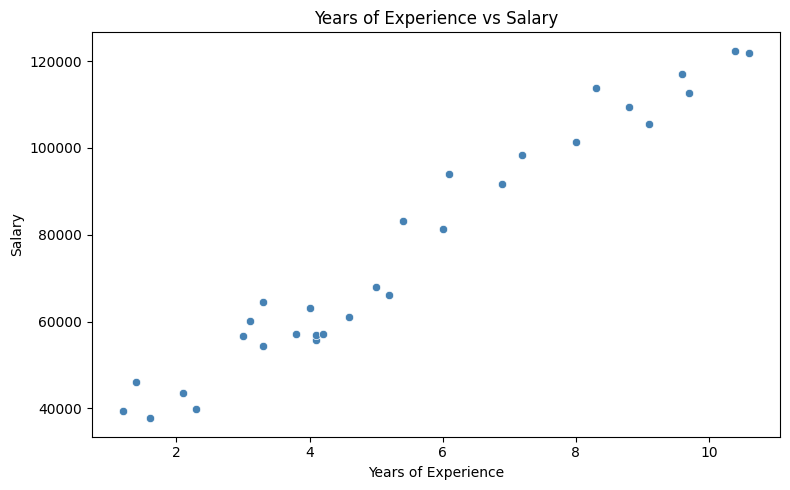

In [67]:
# ── Cell 5: Visualize the raw data ───────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', color='steelblue')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


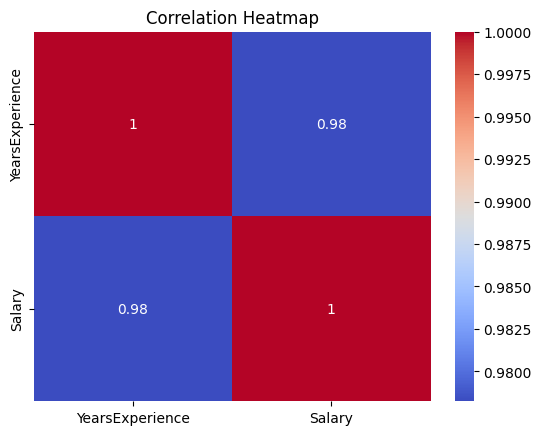

In [68]:
# ── Cell 6: Correlation ───────────────────────────────────────────────────────
print(df.corr())
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [69]:
# ── Cell 7: Prepare features and target ──────────────────────────────────────
X = df[['YearsExperience']]
y = df['Salary']

In [70]:
# ── Cell 8: Fit on FULL dataset (no split) ───────────────────────────────────
model = LinearRegression()
model.fit(X, y)   # X and y — full data, no split

print(f"Intercept  : {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Equation   : Salary = {model.coef_[0]:.2f} * YearsExp + {model.intercept_:.2f}")

Intercept  : 24848.20
Coefficient: 9449.96
Equation   : Salary = 9449.96 * YearsExp + 24848.20


In [71]:
# ── Cell 8: Fit on FULL dataset — NO train_test_split ────────────────────────
model = LinearRegression()
model.fit(X, y)                        # ← full dataset, no split

print(f"Intercept  : {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Equation   : Salary = {model.coef_[0]:.2f} * YearsExp + {model.intercept_:.2f}")

Intercept  : 24848.20
Coefficient: 9449.96
Equation   : Salary = 9449.96 * YearsExp + 24848.20


In [72]:
# ── Cell 10: The regression equation ─────────────────────────────────────────
print(f"Equation: Salary = {model.coef_[0]:.2f} * YearsExperience + {model.intercept_:.2f}")

Equation: Salary = 9449.96 * YearsExperience + 24848.20


In [73]:
# ── Cell 11: Predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)

# Actual vs Predicted table
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
print(results)

     Actual  Predicted
0  112636.0  116512.84
1   67939.0   72098.02
2  113813.0  103282.89
3   83089.0   75878.00
4   64446.0   56033.08
5   57190.0   60758.06


In [74]:
# ── Cell 12: Evaluate the Model ───────────────────────────────────────────────
mae  = np.mean(np.abs(y_test.values - y_pred))
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 6292.99
MSE  : 46452879.75
RMSE : 6815.63
R²   : 0.9091


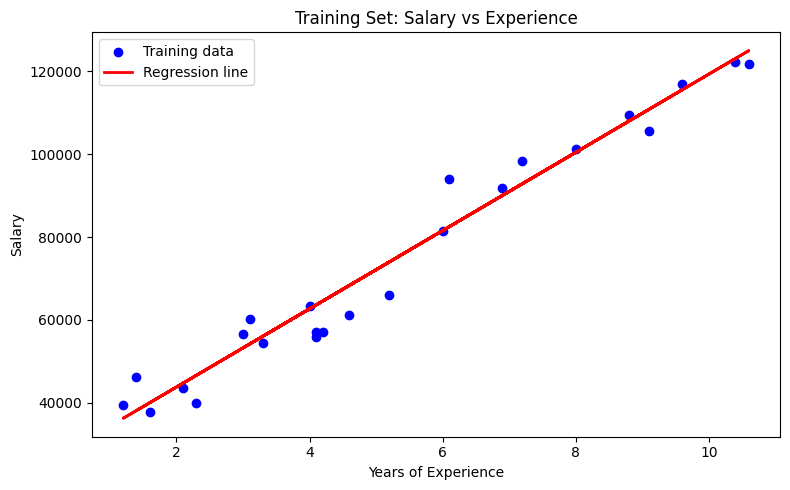

In [75]:
# ── Cell 13: Visualize – Training set ────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.title('Training Set: Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

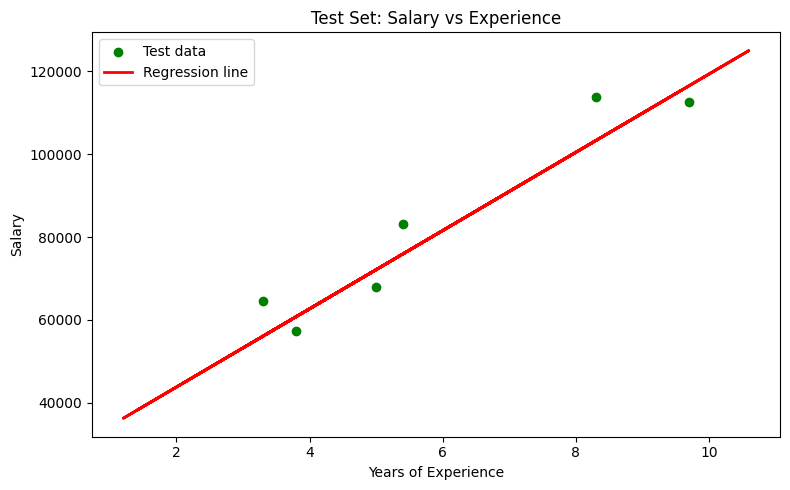

In [76]:
# ── Cell 14: Visualize – Test set ────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.title('Test Set: Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# ── Cell 15: Predict (warning-free) ──────────────────────────────────────────
input_val = pd.DataFrame({'YearsExperience': [6.8]})
pred = model.predict(input_val)[0]
print(f"Predicted Salary for 6.8 years experience: ${pred:,.2f}")
# → $90,051.94 ✅

Predicted Salary for 6.8 years experience: $89,107.95
